# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Q1:**
1. The penalty helps reduce the size of coefficients by making the model "pay" for every unit of coefficient, so that prevents it from going wild and bringing the complex but unnescessary coefficients. This helps keep the model as simple as possible and reduce cost. 

2. The stronger the penalty that the regularization has, the more the coefficients shrink, which usually increases bias but lowers variance. we can, of course, pick the best alpha by cross validation.

3. Ridge shrinks coefficients continuously toward zero, but usually not exactly to zero. LASSO can shrink some coefficients exactly to zero, aka tossing them out and ultimately doing variable selection.  Ridge keeps all predictors with smaller weights, while LASSO gives a model with fewer predictors. Professor raves about LASSO

4. We z-normalize the numeric variables before the regularization to make the penalty fair across features because say we have $100000 for money but 10 for square feet, then this would lead the money to be penalized more, but when we scale them, we put them in similar ranges to allow for more even penalties that makes sense. 

5. By cross validation, using k-fCV and selecting the alpha with the lowest avg mse.

6. I don't think so, the penalty is used on the coefficient while the mse is used to determine which alpha results in the best validation error. 

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

-1.0


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13848094711.21875, tolerance: 12678950600.000021
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 546327167279.78125, tolerance: 12678950600.000021
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1462272063091.4297, tolerance: 12678950600.000021
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.p

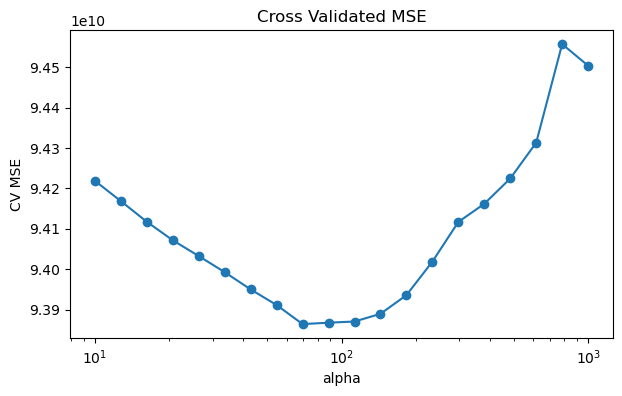

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 259407645318.375, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3637366429880.875, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4830647468312.4375, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: Convergenc

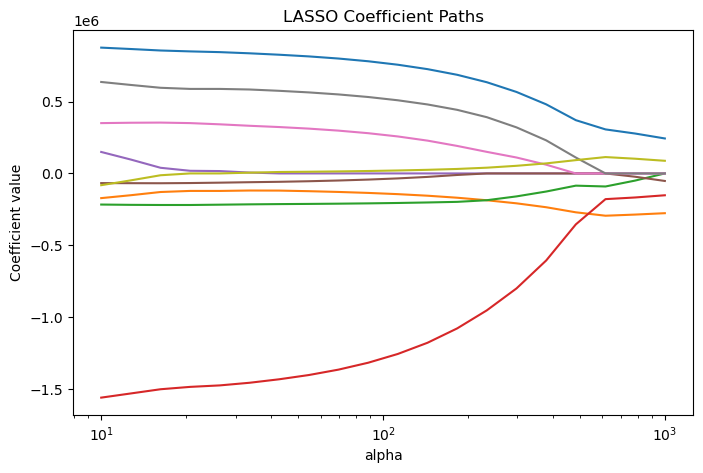

Selected features: ['Mileage_Run', 'Age', 'Mileage_Run^2', 'Mileage_Run Age', 'Age^2', 'Mileage_Run^3', 'Mileage_Run^2 Age', 'Mileage_Run Age^2', 'Age^3']
0.0


,Linear,LASSO
Mileage_Run,9.117748e+05,611783.868767
Age,-2.481722e+05,-397507.787042
Mileage_Run^2,-2.072926e+05,-519555.261867
Mileage_Run Age,-1.671212e+06,-473871.400459
Age^2,3.505507e+05,230721.078724
Mileage_Run^3,-6.514490e+04,97835.641353
Mileage_Run^2 Age,3.388195e+05,318218.774588
Mileage_Run Age^2,7.167816e+05,-35056.210190
Age^3,-2.100379e+05,42493.187416


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import matplotlib.pyplot as plt

cars = pd.read_csv('data/cars_hw.csv')
cars['Age'] = 2026 - cars['Make_Year']

X_base = cars[['Mileage_Run', 'Age']].copy()

#1a

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_base)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

#1b
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

#2
y = cars['Price']
lr = LinearRegression()
lr.fit(X_scaled, y)
coefs_lr = pd.Series(lr.coef_, index=feature_names)
interaction_sign = np.sign(coefs_lr['Mileage_Run Age'])
print(interaction_sign)

#3
alphas = np.logspace(1, 3, 20)
lasso = LassoCV(alphas=alphas, cv=20, random_state=100)
lasso.fit(X_scaled, y)
coefs_lasso = pd.Series(lasso.coef_, index=feature_names)

#4
plt.figure(figsize=(7,4))
plt.plot(lasso.alphas_, np.mean(lasso.mse_path_, axis=1), marker='o')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV MSE')
plt.title('Cross Validated MSE')
plt.show()

#5
plt.figure(figsize=(8,5))
for i in range(len(feature_names)):
    plt.plot(lasso.alphas_, lasso.path(X_scaled, y, alphas=alphas, max_iter=10000)[1][i], label=feature_names[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()


#6
selected = coefs_lasso[coefs_lasso != 0]
proportion_zero = (coefs_lasso == 0).mean()
print(f"Selected features: {selected.index.tolist()}")
print(proportion_zero)

#7
comparison = pd.DataFrame({'Linear': coefs_lr, 'LASSO': coefs_lasso})
comparison
#The ones that increases are mileage_run^2, age, and mileage_run^3. sign was changed for mileage_run^3, mileage_run Age^2 and age^3.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

Linear Regression coefficients:
 age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.07215

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.30161237846821365, tolerance: 0.0058323943661972065
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.28065391906846315, tolerance: 0.0058323943661972065
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.067808304768942, tolerance: 0.0058323943661972065
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinat

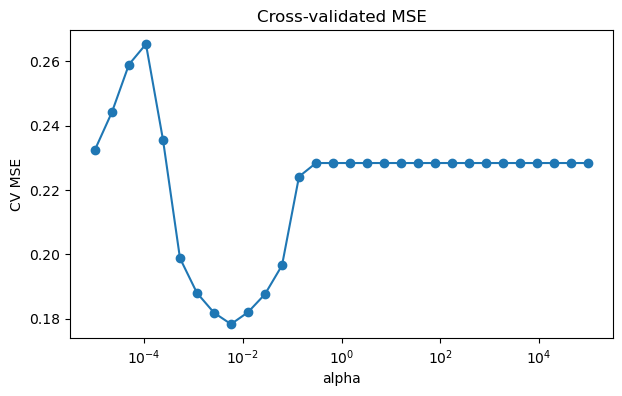

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1716061378009499, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.5219974730751886, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6.227442241959032, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_des

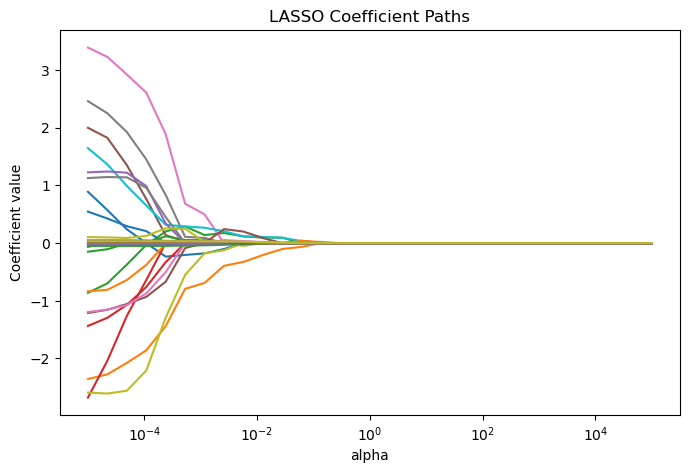

Selected features: ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'smoking', 'anaemia diabetes', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']
Proportion set to zero: 0.5862068965517241


,LinearRegression,LASSO
age,1.539156,-0.000000
ejection_fraction,-2.192494,-0.326124
serum_creatinine,-0.853588,0.117426
age^2,-3.678654,0.000000
age ejection_fraction,-0.600918,-0.000000
age serum_creatinine,1.841563,0.000000
ejection_fraction^2,3.430976,0.000000
ejection_fraction serum_creatinine,2.673394,0.000000
serum_creatinine^2,-2.647041,-0.000000
age^3,1.993135,0.116214


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import matplotlib.pyplot as plt

#1
heart = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
cont_vars = ['age', 'ejection_fraction', 'serum_creatinine']
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly_cont.fit_transform(heart[cont_vars])
cont_feature_names = poly_cont.get_feature_names_out(cont_vars)
cat_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(heart[cat_vars])
cat_feature_names = poly_cat.get_feature_names_out(cat_vars)
X = np.hstack([X_cont, X_cat])
feature_names = np.concatenate([cont_feature_names, cat_feature_names])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#2
y = heart['DEATH_EVENT']
lr = LinearRegression()
lr.fit(X_scaled, y)
coefs_lr = pd.Series(lr.coef_, index=feature_names)
print("Linear Regression coefficients:\n", coefs_lr)
#variables like smoking, diabetes, and high bloo dpressure have negative coefficients, which makes no sense becuase these things are likely to increase death risk. This can be due to multicolinearity because when we do the high-order interactions with these variables, we are able to see positive coefficients which means these predictors' effects are affected by other predictors, thus it is hard to really determien thier inividual effects. 

#3
alphas = np.logspace(-5, 5, 30)
lasso = LassoCV(alphas=alphas, cv=20, random_state=100)
lasso.fit(X_scaled, y)
coefs_lasso = pd.Series(lasso.coef_, index=feature_names)

#4
plt.figure(figsize=(7,4))
plt.plot(lasso.alphas_, np.mean(lasso.mse_path_, axis=1), marker='o')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV MSE')
plt.title('Cross-validated MSE')
plt.show()

#5
plt.figure(figsize=(8,5))
for i in range(len(feature_names)):
    plt.plot(lasso.alphas_, lasso.path(X_scaled, y, alphas=alphas, max_iter=10000)[1][i], label=feature_names[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()

#6
selected = coefs_lasso[coefs_lasso != 0]
proportion_zero = (coefs_lasso == 0).mean()
print(f"Selected features: {selected.index.tolist()}")
print(f"Proportion set to zero: {proportion_zero}")

comparison = pd.DataFrame({'LinearRegression': coefs_lr, 'LASSO': coefs_lasso})
comparison

# The only coefficient that increased is anaemia, and as for sign change, most did except for high_blood_pressure x smoking, diabetes x smoking, diabetes x high_blood_pressure, anaemia x diabetes, smoking, age^3 and ejection fraction
# The sign pattern of the LASSO makes more sense since it helps get rid of the noise by setting them to 0 and keeping around only the most needed features. THe linear reg keeps around all of the coefficients whuich ony adds to the noise and give more variance because we could be overfitting.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![homework 5, question 4 answers](images/hw5_q4.jpeg)